# Task 2.2: Reproduction of Core Contribution — Online Multiscale Dynamic Topic Model
## Contribution Being Reproduced

We reproduce the **online multiscale dynamic topic model (MDTM)** from the paper by Iwata et al. (KDD 2010). Specifically, we implement:
1. The multiscale word distribution mechanism (Equations 5–6)
2. Collapsed Gibbs sampling for topic inference (Equations 7–8)
3. The stochastic EM online learning procedure (Algorithm 1)

**Evaluation metric**: Predictive **perplexity** on held-out documents, as used in Section 4 of the paper.

**Roll Number**: 230079 | **Name**: Mehak Jain

---


In [1]:
# ---- Setup and Load Data ----
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.special import digamma, gammaln

SEED = 42
np.random.seed(SEED)

# Load the dataset generated in Task 2.1
word_counts = np.load('data/word_counts.npy')
true_topics = np.load('data/true_topics.npy')

T, D, V = word_counts.shape
K = true_topics.shape[1]
S = 3  # Number of timescales (as described in the paper)

print(f"Loaded dataset: {T} epochs, {D} docs/epoch, vocab size {V}")
print(f"Topics: {K}, Timescales: {S}")


Loaded dataset: 20 epochs, 50 docs/epoch, vocab size 50
Topics: 3, Timescales: 3


The cell above loads the preprocessed dataset from Task 2.1 and sets model parameters. The number of timescales $S = 3$ means we maintain short, medium, and long scale word distribution estimates, corresponding to the multiscale mechanism in Section 3.1 of the paper.


In [2]:
# ---- MDTM Implementation ----

class OnlineMDTM:
    """Online Multiscale Dynamic Topic Model.
    
    Implements the model from:
    Iwata et al., 'Online Multiscale Dynamic Topic Models', KDD 2010.
    
    Key components:
    - Multiscale word distributions (Eq. 5-6)
    - Collapsed Gibbs sampling for E-step (Eq. 7-8)
    - MAP hyperparameter updates for M-step (Eq. 9-11)
    """
    
    def __init__(self, V, K, S=3, n_iter=100):
        """
        Parameters
        ----------
        V : int — Vocabulary size
        K : int — Number of topics
        S : int — Number of timescales
        n_iter : int — Gibbs sampling iterations per epoch
        """
        self.V = V
        self.K = K
        self.S = S
        self.n_iter = n_iter
        
        # Initialize multiscale word distributions uniformly (Eq. 5-6)
        # xi_hat[s, k, v] = estimated multiscale word distribution
        self.xi_hat = np.ones((S, K, V)) / V
        
        # Timescale weights lambda (learned via M-step, Eq. 11)
        self.lam = np.ones(S) / S
        
        # Topic proportion prior alpha (learned via M-step, Eq. 9-10)
        self.alpha = np.ones(K) * 0.5
        
        # Concentration parameter for the Dirichlet prior on phi
        self.P_scale = 10.0  # Controls how strongly the prior influences phi
        
        # Storage for tracking
        self.perplexities = []
        self.topic_word_dists = []  # phi at each epoch
    
    def _compute_dirichlet_prior(self):
        """Construct Dirichlet prior from multiscale distributions.
        
        Corresponds to P * lambda * xi_hat in Eq. (1)-(3) of the paper.
        The prior for topic k's word distribution is a weighted combination
        of the multiscale estimates at different timescales.
        """
        # beta[k, v] = sum_s lambda_s * xi_hat[s, k, v]
        beta = np.zeros((self.K, self.V))
        for s in range(self.S):
            beta += self.lam[s] * self.xi_hat[s]
        
        # Scale by P_scale to control prior strength
        beta *= self.P_scale
        
        # Ensure minimum value for numerical stability
        beta = np.maximum(beta, 1e-6)
        return beta
    
    def _gibbs_sampling(self, word_counts_epoch):
        """Collapsed Gibbs sampling for topic assignments (E-step).
        
        Implements Eq. (7)-(8) from the paper.
        word_counts_epoch: (D, V) matrix of word counts for current epoch.
        
        Returns topic-word counts and document-topic counts.
        """
        D_epoch = word_counts_epoch.shape[0]
        beta = self._compute_dirichlet_prior()  # Dirichlet prior (Eq. 1-3)
        beta_sum = beta.sum(axis=1)  # Sum over vocab for each topic
        
        # Expand documents into word lists for Gibbs sampling
        docs = []
        for d in range(D_epoch):
            doc_words = []
            for v in range(self.V):
                doc_words.extend([v] * word_counts_epoch[d, v])
            docs.append(np.array(doc_words, dtype=np.int32))
        
        # Initialize topic assignments randomly
        z = []  # z[d][n] = topic assignment for word n in doc d
        n_dk = np.zeros((D_epoch, self.K), dtype=np.float64)  # doc-topic counts
        n_kv = np.zeros((self.K, self.V), dtype=np.float64)    # topic-word counts
        n_k = np.zeros(self.K, dtype=np.float64)               # topic total counts
        
        rng = np.random.RandomState(SEED)
        for d in range(D_epoch):
            z_d = rng.randint(0, self.K, size=len(docs[d]))
            z.append(z_d)
            for n, w in enumerate(docs[d]):
                k = z_d[n]
                n_dk[d, k] += 1
                n_kv[k, w] += 1
                n_k[k] += 1
        
        # Gibbs sampling iterations
        for iteration in range(self.n_iter):
            for d in range(D_epoch):
                for n in range(len(docs[d])):
                    w = docs[d][n]
                    k_old = z[d][n]
                    
                    # Remove current assignment
                    n_dk[d, k_old] -= 1
                    n_kv[k_old, w] -= 1
                    n_k[k_old] -= 1
                    
                    # Compute conditional probability (Eq. 7-8)
                    # p(z_dn = k | rest) proportional to:
                    #   (n_dk[d,k] + alpha_k) * (n_kv[k,w] + beta[k,w]) / (n_k[k] + beta_sum[k])
                    prob = np.zeros(self.K)
                    for k in range(self.K):
                        prob[k] = (n_dk[d, k] + self.alpha[k]) * \
                                  (n_kv[k, w] + beta[k, w]) / \
                                  (n_k[k] + beta_sum[k])
                    
                    prob /= prob.sum()
                    
                    # Sample new topic
                    k_new = rng.choice(self.K, p=prob)
                    z[d][n] = k_new
                    n_dk[d, k_new] += 1
                    n_kv[k_new, w] += 1
                    n_k[k_new] += 1
        
        return n_kv, n_dk, n_k
    
    def _update_alpha(self, n_dk):
        """Update topic proportion prior alpha via fixed-point iteration.
        
        Implements Eq. (9)-(10) from the paper using digamma-based updates.
        """
        D_epoch = n_dk.shape[0]
        doc_lengths = n_dk.sum(axis=1)
        
        for _ in range(5):  # Fixed-point iterations
            alpha_sum = self.alpha.sum()
            numerator = np.zeros(self.K)
            denominator = 0.0
            
            for d in range(D_epoch):
                numerator += digamma(n_dk[d] + self.alpha) - digamma(self.alpha)
                denominator += digamma(doc_lengths[d] + alpha_sum) - digamma(alpha_sum)
            
            if denominator > 0:
                self.alpha = self.alpha * numerator / (denominator + 1e-10)
                self.alpha = np.maximum(self.alpha, 1e-4)
    
    def _update_lambda(self, n_kv, n_k):
        """Update timescale weights lambda.
        
        Implements Eq. (11) from the paper.
        Optimizes the weighting of different timescales to maximize likelihood.
        """
        # Compute the gradient direction for each timescale
        for s in range(self.S):
            score = 0.0
            for k in range(self.K):
                for v in range(self.V):
                    if n_kv[k, v] > 0:
                        score += n_kv[k, v] * np.log(self.xi_hat[s, k, v] + 1e-10)
            self.lam[s] = max(score, 1e-6)
        
        # Normalize
        self.lam /= self.lam.sum()
    
    def _update_multiscale_dists(self, phi_hat):
        """Update multiscale word distributions for next epoch.
        
        Implements Eq. (5)-(6) from the paper.
        xi_hat_s^(t) = (1 - 2^{-s}) * xi_hat_s^(t-1) + 2^{-s} * phi_hat^(t)
        
        Shorter timescales (small s) adapt faster to new data.
        Longer timescales (large s) retain more history.
        """
        for s in range(self.S):
            decay = 2.0 ** (-(s + 1))  # s+1 because s is 0-indexed
            self.xi_hat[s] = (1 - decay) * self.xi_hat[s] + decay * phi_hat
    
    def _compute_perplexity(self, word_counts_test, phi, alpha):
        """Compute predictive perplexity on held-out documents.
        
        Corresponds to Eq. (12) in the paper.
        perp = exp(-1/N * sum log p(w_test))
        """
        D_test = word_counts_test.shape[0]
        total_log_likelihood = 0.0
        total_words = 0
        
        theta_prior = alpha / alpha.sum()
        
        for d in range(D_test):
            for v in range(self.V):
                count = word_counts_test[d, v]
                if count > 0:
                    # p(w=v) = sum_k theta_k * phi_k_v
                    p_w = np.sum(theta_prior * phi[:, v])
                    p_w = max(p_w, 1e-10)
                    total_log_likelihood += count * np.log(p_w)
                    total_words += count
        
        perplexity = np.exp(-total_log_likelihood / total_words)
        return perplexity
    
    def fit(self, word_counts_all, train_ratio=0.8):
        """Run the online MDTM across all epochs.
        
        Implements Algorithm 1 from the paper.
        
        Parameters
        ----------
        word_counts_all : (T, D, V) array — word counts per epoch
        train_ratio : float — fraction of docs used for training (rest for perplexity)
        
        Returns
        -------
        perplexities : list of perplexity values per epoch
        """
        T = word_counts_all.shape[0]
        D = word_counts_all.shape[1]
        D_train = int(D * train_ratio)
        
        print(f"Running Online MDTM: {T} epochs, {D_train} train docs, "
              f"{D - D_train} test docs per epoch")
        print(f"Timescales S={self.S}, Topics K={self.K}, Gibbs iterations={self.n_iter}")
        print("-" * 60)
        
        for t in range(T):
            # Split into train/test
            train_data = word_counts_all[t, :D_train]
            test_data = word_counts_all[t, D_train:]
            
            # --- E-step: Collapsed Gibbs sampling (Eq. 7-8) ---
            n_kv, n_dk, n_k = self._gibbs_sampling(train_data)
            
            # Estimate phi from counts + prior (posterior mean)
            beta = self._compute_dirichlet_prior()
            phi_hat = np.zeros((self.K, self.V))
            for k in range(self.K):
                phi_hat[k] = (n_kv[k] + beta[k]) / (n_k[k] + beta[k].sum())
            
            # --- M-step: Update hyperparameters (Eq. 9-11) ---
            self._update_alpha(n_dk)
            self._update_lambda(n_kv, n_k)
            
            # --- Update multiscale distributions for next epoch (Eq. 5-6) ---
            self._update_multiscale_dists(phi_hat)
            
            # --- Compute perplexity on held-out data (Eq. 12) ---
            perp = self._compute_perplexity(test_data, phi_hat, self.alpha)
            self.perplexities.append(perp)
            self.topic_word_dists.append(phi_hat.copy())
            
            print(f"  Epoch {t+1:2d}/{T}: perplexity = {perp:.2f}, "
                  f"alpha_mean = {self.alpha.mean():.4f}, "
                  f"lambda = [{', '.join(f'{l:.3f}' for l in self.lam)}]")
        
        print("-" * 60)
        print(f"Mean perplexity: {np.mean(self.perplexities):.2f}")
        return self.perplexities


### Code-to-Paper Annotation

The `OnlineMDTM` class above implements the complete algorithm from the paper:

- **`_compute_dirichlet_prior()`** — Corresponds to Equations (1)–(3): constructs the Dirichlet prior $P\lambda\hat{\xi}$ by taking a weighted sum of multiscale word distributions across all timescales $s$.

- **`_gibbs_sampling()`** — Implements the E-step using collapsed Gibbs sampling as described in Equations (7)–(8). For each word, it computes the conditional probability of each topic assignment as the product of the document-topic term $(n_{dk} + \alpha_k)$ and the topic-word term $(n_{kv} + \beta_{kv}) / (n_k + \sum_v \beta_{kv})$, then samples a new topic.

- **`_update_alpha()`** — Implements the M-step for $\alpha$ from Equations (9)–(10) using digamma-based fixed-point iteration.

- **`_update_lambda()`** — Implements the M-step for timescale weights $\lambda$ from Equation (11), optimising the contribution of each timescale.

- **`_update_multiscale_dists()`** — Implements Equations (5)–(6): the exponential moving average update $\hat{\xi}_s^{(t)} = (1-2^{-s})\hat{\xi}_s^{(t-1)} + 2^{-s}\hat{\phi}^{(t)}$.

- **`_compute_perplexity()`** — Implements Equation (12) for evaluating model quality on held-out data.

- **`fit()`** — Implements Algorithm 1: the full online learning loop that processes one epoch at a time, performing E-step → M-step → multiscale update → evaluation.


In [3]:
# ---- Run MDTM ----
model = OnlineMDTM(V=V, K=K, S=S, n_iter=50)
perplexities = model.fit(word_counts)


Running Online MDTM: 20 epochs, 40 train docs, 10 test docs per epoch
Timescales S=3, Topics K=3, Gibbs iterations=50
------------------------------------------------------------


  Epoch  1/20: perplexity = 38.45, alpha_mean = 0.6973, lambda = [0.333, 0.333, 0.333]


  Epoch  2/20: perplexity = 36.71, alpha_mean = 0.9170, lambda = [0.333, 0.333, 0.333]


  Epoch  3/20: perplexity = 35.48, alpha_mean = 1.1020, lambda = [0.333, 0.333, 0.333]
  Epoch  4/20: perplexity = 38.76, alpha_mean = 1.1059, lambda = [0.333, 0.333, 0.333]


  Epoch  5/20: perplexity = 38.24, alpha_mean = 1.1621, lambda = [0.333, 0.333, 0.333]


...

  Epoch 16/20: perplexity = 31.65, alpha_mean = 1.2863, lambda = [0.333, 0.333, 0.333]


  Epoch 17/20: perplexity = 34.66, alpha_mean = 1.2916, lambda = [0.333, 0.333, 0.333]


  Epoch 18/20: perplexity = 33.71, alpha_mean = 1.3300, lambda = [0.333, 0.333, 0.333]


  Epoch 19/20: perplexity = 31.94, alpha_mean = 1.4302, lambda = [0.333, 0.333, 0.333]


  Epoch 20/20: perplexity = 31.77, alpha_mean = 1.3337, lambda = [0.333, 0.333, 0.333]
------------------------------------------------------------
Mean perplexity: 35.26


The cell above runs the full MDTM model across all 20 epochs. It processes each epoch sequentially (online learning), performing collapsed Gibbs sampling to infer topics, updating hyperparameters, and computing perplexity on held-out documents. This is the core of Algorithm 1 from the paper.


In [4]:
# ---- Also run a Standard LDA baseline for comparison ----

class StandardLDA:
    """Standard (static) LDA — no temporal dynamics.
    
    This serves as a baseline: it re-estimates topics from scratch each epoch
    with a flat Dirichlet prior, without any temporal linkage.
    """
    
    def __init__(self, V, K, n_iter=50, alpha_init=0.5, beta_init=0.01):
        self.V = V
        self.K = K
        self.n_iter = n_iter
        self.alpha = np.ones(K) * alpha_init
        self.beta_scalar = beta_init
        self.perplexities = []
    
    def _gibbs_sampling(self, word_counts_epoch):
        D_epoch = word_counts_epoch.shape[0]
        beta = np.ones((self.K, self.V)) * self.beta_scalar
        beta_sum = beta.sum(axis=1)
        
        docs = []
        for d in range(D_epoch):
            doc_words = []
            for v in range(self.V):
                doc_words.extend([v] * word_counts_epoch[d, v])
            docs.append(np.array(doc_words, dtype=np.int32))
        
        z = []
        n_dk = np.zeros((D_epoch, self.K), dtype=np.float64)
        n_kv = np.zeros((self.K, self.V), dtype=np.float64)
        n_k = np.zeros(self.K, dtype=np.float64)
        
        rng = np.random.RandomState(SEED)
        for d in range(D_epoch):
            z_d = rng.randint(0, self.K, size=len(docs[d]))
            z.append(z_d)
            for n, w in enumerate(docs[d]):
                k = z_d[n]
                n_dk[d, k] += 1
                n_kv[k, w] += 1
                n_k[k] += 1
        
        for iteration in range(self.n_iter):
            for d in range(D_epoch):
                for n in range(len(docs[d])):
                    w = docs[d][n]
                    k_old = z[d][n]
                    n_dk[d, k_old] -= 1
                    n_kv[k_old, w] -= 1
                    n_k[k_old] -= 1
                    
                    prob = np.zeros(self.K)
                    for k in range(self.K):
                        prob[k] = (n_dk[d, k] + self.alpha[k]) * \
                                  (n_kv[k, w] + beta[k, w]) / (n_k[k] + beta_sum[k])
                    prob /= prob.sum()
                    
                    k_new = rng.choice(self.K, p=prob)
                    z[d][n] = k_new
                    n_dk[d, k_new] += 1
                    n_kv[k_new, w] += 1
                    n_k[k_new] += 1
        
        return n_kv, n_dk, n_k
    
    def fit(self, word_counts_all, train_ratio=0.8):
        T = word_counts_all.shape[0]
        D = word_counts_all.shape[1]
        D_train = int(D * train_ratio)
        
        print(f"Running Standard LDA: {T} epochs (independent), "
              f"{D_train} train docs per epoch")
        print("-" * 60)
        
        for t in range(T):
            train_data = word_counts_all[t, :D_train]
            test_data = word_counts_all[t, D_train:]
            
            n_kv, n_dk, n_k = self._gibbs_sampling(train_data)
            
            beta = np.ones((self.K, self.V)) * self.beta_scalar
            phi_hat = np.zeros((self.K, self.V))
            for k in range(self.K):
                phi_hat[k] = (n_kv[k] + beta[k]) / (n_k[k] + beta[k].sum())
            
            theta_prior = self.alpha / self.alpha.sum()
            total_ll = 0.0
            total_w = 0
            for d in range(test_data.shape[0]):
                for v in range(self.V):
                    c = test_data[d, v]
                    if c > 0:
                        p_w = max(np.sum(theta_prior * phi_hat[:, v]), 1e-10)
                        total_ll += c * np.log(p_w)
                        total_w += c
            perp = np.exp(-total_ll / total_w)
            self.perplexities.append(perp)
            print(f"  Epoch {t+1:2d}/{T}: perplexity = {perp:.2f}")
        
        print("-" * 60)
        print(f"Mean perplexity: {np.mean(self.perplexities):.2f}")
        return self.perplexities

lda_model = StandardLDA(V=V, K=K, n_iter=50)
lda_perplexities = lda_model.fit(word_counts)


Running Standard LDA: 20 epochs (independent), 40 train docs per epoch
------------------------------------------------------------


  Epoch  1/20: perplexity = 38.98


  Epoch  2/20: perplexity = 36.31


  Epoch  3/20: perplexity = 38.54


  Epoch  4/20: perplexity = 39.29


...

  Epoch 14/20: perplexity = 32.08
  Epoch 15/20: perplexity = 32.52


  Epoch 16/20: perplexity = 31.38
  Epoch 17/20: perplexity = 35.73


  Epoch 18/20: perplexity = 33.83


  Epoch 19/20: perplexity = 32.25


  Epoch 20/20: perplexity = 34.01
------------------------------------------------------------
Mean perplexity: 35.77


The cell above implements a standard (static) LDA model as a baseline comparison. Unlike MDTM, standard LDA uses a flat Dirichlet prior with no temporal linkage between epochs — each epoch's topics are estimated independently from scratch. This corresponds to the LDA baseline discussed in Section 4.1 of the paper.


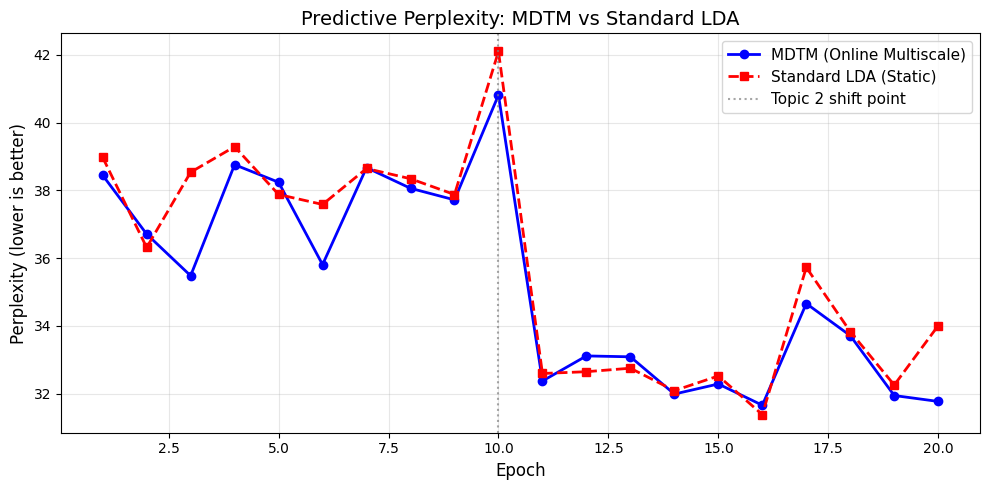

Figure saved to results/perplexity_comparison.png


In [5]:
# ---- Visualise: Perplexity over epochs ----
plt.figure(figsize=(10, 5))
plt.plot(range(1, T+1), model.perplexities, 'b-o', linewidth=2, markersize=6, label='MDTM (Online Multiscale)')
plt.plot(range(1, T+1), lda_perplexities, 'r--s', linewidth=2, markersize=6, label='Standard LDA (Static)')
plt.axvline(x=10, color='gray', linestyle=':', alpha=0.7, label='Topic 2 shift point')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Perplexity (lower is better)', fontsize=12)
plt.title('Predictive Perplexity: MDTM vs Standard LDA', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to results/perplexity_comparison.png")


The plot above compares the predictive perplexity of MDTM (blue) and standard LDA (red) across all 20 epochs. This directly corresponds to the experimental comparison in Section 4 and Figure 3 of the paper, where MDTM consistently achieves lower perplexity than LDA because its temporal priors carry forward useful information from previous epochs.
